make the final figure for the paper

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from skimage.segmentation import find_boundaries
import matplotlib.colors as mcolors
import tifffile
import scikit_posthocs as sp
from scipy.stats import kruskal
from sklearn.mixture import GaussianMixture
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from scipy.stats import ttest_ind
import statsmodels.formula.api as smf
from itertools import combinations

In [ ]:
PN_L_ROI = ['IMC8_001', 'IMC15_004', 'IMC1_004', 'IMC14_004', 'IMC15_003', 'IMC13_001', 'IMC16_004', 'IMC9_005', 'IMC10_004']
PN_NL_ROI = ['IMC8_005', 'IMC10_003', 'IMC15_001', 'IMC1_001', 'IMC15_002', 'IMC13_002']
HC_ROI = ['IMC2_005', 'IMC3_005', 'IMC4_003', 'IMC5_001', 'IMC6_001','IMC7_001', 'IMC8_003', 'IMC14_001', 'IMC15_005']

sample_group_df = pd.DataFrame(
    [
        {'sample': sample, 'group': 'PN_L_ROI'} for sample in PN_L_ROI
    ]
    + [
        {'sample': sample, 'group': 'PN_NL_ROI'} for sample in PN_NL_ROI
    ]
    + [
        {'sample': sample, 'group': 'HC_ROI'} for sample in HC_ROI
    ]
)


#read in all sample data
to_concat = []
for f in sample_group_df['sample']:
    to_concat.append(
        pd.read_csv(f'./roi_output/{f}/{f}_cells.csv')
    )

all_cells = pd.concat(to_concat, ignore_index=True)
all_cells = pd.merge(all_cells, sample_group_df, right_on='sample', left_on='roi')
all_cells = all_cells.drop(columns=['label', 'area', 'eccentricity', 'perimeter', 'solidity','centroid_y', 'centroid_x', 'area_um2', 'sample'])
all_cells = all_cells[['roi', 'compartment', 'group'] + list(all_cells.columns[2:-1])]
all_cells.columns = [c.split('_')[-1] for c in all_cells.columns]
all_cells.rename(columns={'IL7':'IL17', 'IL7RA':'IL17RA'}, inplace=True)

# split all cells into dermal and epidermal
dermal_cells = all_cells[~(all_cells['compartment'] == 'epidermis')]
epidermal_cells = all_cells[all_cells['compartment'] == 'epidermis']

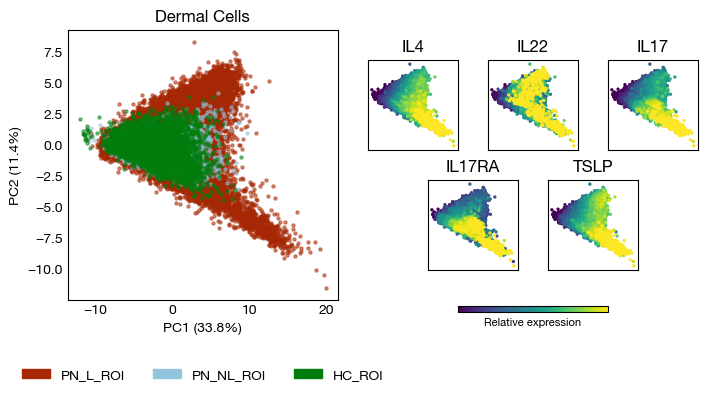

In [58]:
### pca of cells per compartment labeled by group

#make the figure
# figure size
WIDTH = 6
HEIGHT = 6

# figure style
plt.rcParams.update(plt.rcParamsDefault)
%matplotlib inline
plt.rcParams['font.family'] = 'Helvetica Neue'
plt.rcParams['font.size'] = 10
plt.rcParams['xtick.major.size'] = 0
plt.rcParams['ytick.major.size'] = 0
plt.rcParams['pdf.fonttype'] = 42 # need this to open/edit in illustrator - if needed

fig = plt.figure(figsize=(WIDTH, HEIGHT))

### add the axes
ax_full_pca = fig.add_axes([0.05, 0.35, 0.45, 0.45])
ax_marker1 = fig.add_axes([0.55, 0.6, 0.15, 0.15])
ax_marker2 = fig.add_axes([0.75, 0.6, 0.15, 0.15])
ax_marker3 = fig.add_axes([0.95, 0.6, 0.15, 0.15])
ax_marker4 = fig.add_axes([0.65, 0.4, 0.15, 0.15])
ax_marker5 = fig.add_axes([0.85, 0.4, 0.15, 0.15])
ax_legend_group = fig.add_axes([0.15, 0.20, 0.25, 0.05])
ax_cbar_expression = fig.add_axes([0.70, 0.33, 0.25, 0.01])


###### plot the dermal pca
z_order = ['PN_L_ROI', 'PN_NL_ROI', 'HC_ROI']
palette = ['#a62703', '#92c4e0', '#017d0e']
color_map = dict(zip(z_order, palette))

pca = PCA(n_components=2)
scaler = StandardScaler()

# plot the dermis pca
dermal_scaled = scaler.fit_transform(dermal_cells.drop(columns=['roi', 'compartment', 'group']))
dermal_cells_pca = pd.DataFrame(pca.fit_transform(dermal_scaled))
dermal_cells_pca = pd.concat([
    dermal_cells['group'].reset_index(drop=True), dermal_cells_pca
], axis=1)
dermis_var = pca.explained_variance_ratio_  # capture after fit

ax = ax_full_pca
for group in z_order:
    subset = dermal_cells_pca[dermal_cells_pca['group'] == group]
    ax.scatter(subset[0], subset[1], label=group, color=color_map[group], zorder=z_order.index(group), s=5, alpha=0.5)
ax.set_xlabel(f'PC1 ({dermis_var[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({dermis_var[1]*100:.1f}%)')
ax.set_title("Dermal Cells")

# legend on its own axes
patches = [mpatches.Patch(color=color_map[g], label=g) for g in z_order]
ax_legend_group.legend(handles=patches, loc='center', ncol=len(z_order), frameon=False)
ax_legend_group.axis('off')


###### plot each of the markers
targets = ['IL4', 'IL22', 'IL17', 'IL17RA', 'TSLP']
axes = [ax_marker1, ax_marker2, ax_marker3, ax_marker4, ax_marker5]
for t, ax_pca in zip(targets, axes):
    dermal_cells_pca_target = pd.concat([
        dermal_cells[[t, 'roi']].reset_index(drop=True),
        dermal_cells_pca
    ], axis=1)

    plot_df = dermal_cells_pca_target.sort_values(t)
    vlo, vhi = np.percentile(plot_df[t], [2, 98])
    sc = ax_pca.scatter(plot_df[0], plot_df[1], c=plot_df[t], s=2,
                        vmin=vlo, vmax=vhi)
    ax_pca.set_xticklabels([])
    ax_pca.set_yticklabels([])
    #ax_pca.set_xlabel(f'PC1 ({dermis_var[0]*100:.1f}%)', fontsize=8)
    #ax_pca.set_ylabel(f'PC2 ({dermis_var[1]*100:.1f}%)', fontsize=8)
    ax_pca.set_title(f"{t}", fontsize=12)


cbar = fig.colorbar(sc, cax=ax_cbar_expression, orientation='horizontal')
cbar.set_label('Relative expression', fontsize=8)
cbar.set_ticks([])


fig.savefig('FIG1.pdf', bbox_inches='tight')
fig.savefig('FIG1.png', bbox_inches='tight')

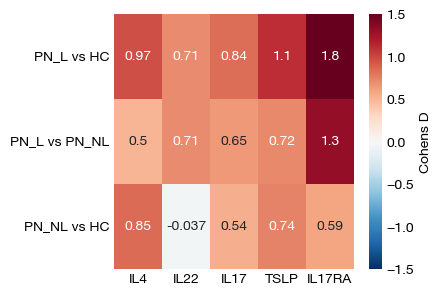

In [59]:
###  make a heatmap of cohens-d distances

def cohens_d(a, b):
    """d = (mean_a - mean_b) / pooled_sd. Sign: + means a > b."""
    a, b = np.asarray(a), np.asarray(b)
    pooled = np.sqrt((np.var(a, ddof=1) + np.var(b, ddof=1)) / 2)
    return (a.mean() - b.mean()) / pooled if pooled > 0 else np.nan


def effect_sizes(df, target, group_col='group',
                 z_order=['PN_L_ROI', 'PN_NL_ROI', 'HC_ROI']):
    """Per-ROI mean intensity, pairwise Cohen's d between groups."""
    roi_means = (df.groupby(['roi', group_col])[target]
                   .mean().reset_index(name='val'))
    
    pairs = [('PN_L_ROI', 'HC_ROI'),
             ('PN_L_ROI', 'PN_NL_ROI'),
             ('PN_NL_ROI', 'HC_ROI')]
    
    rows = []
    for a, b in pairs:
        va = roi_means.loc[roi_means[group_col] == a, 'val']
        vb = roi_means.loc[roi_means[group_col] == b, 'val']
        rows.append({
            'comparison': f'{a} vs {b}',
            'mean_a':     va.mean(),
            'mean_b':     vb.mean(),
            'fold':       va.mean() / vb.mean() if vb.mean() > 0 else np.nan,
            'cohens_d':   cohens_d(va, vb),
        })
    return pd.DataFrame(rows)

markers = ['IL4', 'IL22', 'IL17', 'TSLP','IL17RA']
ds = pd.DataFrame({m: effect_sizes(dermal_cells, m)['cohens_d'].values 
                   for m in markers},
                  index=['PN_L vs HC', 'PN_L vs PN_NL', 'PN_NL vs HC'])



# figure size
WIDTH = 4
HEIGHT = 3

# figure style
plt.rcParams.update(plt.rcParamsDefault)
%matplotlib inline
plt.rcParams['font.family'] = 'Helvetica Neue'
plt.rcParams['font.size'] = 10
plt.rcParams['xtick.major.size'] = 0
plt.rcParams['ytick.major.size'] = 0
plt.rcParams['pdf.fonttype'] = 42

fig = plt.figure(figsize=(WIDTH, HEIGHT))

### add the axes
ax_heatmap = fig.add_axes([0.05, 0.05, 0.75, 0.85])

sns.heatmap(ds, annot=True, cmap='RdBu_r', center=0, vmin=-1.5, vmax=1.5, ax=ax_heatmap, cbar_kws={'label': 'Cohens D'})

fig.savefig(f'FIG2.pdf', bbox_inches='tight')

fig.savefig(f'FIG2.png', bbox_inches='tight')
